In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import r2_score
import statsmodels.formula.api as smf


In [7]:
def r2(pred_file_path):

    pred_ptr_df = pd.read_csv(pred_file_path, sep='\t')

    r2_scores = []
    for tissue in pred_ptr_df["tissue"].unique():

        observed = pred_ptr_df[pred_ptr_df['tissue'] == tissue]['PTR']
        predicted = pred_ptr_df[pred_ptr_df['tissue'] == tissue]['predicted_PTR']
        scores = r2_score(observed, predicted)
        r2_scores.append(scores)

    r2_scores = np.array(r2_scores) 
    median_r2 = np.median(r2_scores)
    filename = os.path.basename(pred_file_path)

    print(filename)
    print('Median R² across all tissues: ' + str(median_r2))
    print(pd.DataFrame({
        'Tissue': pred_ptr_df["tissue"].unique(),
        '(Mean) R²': r2_scores
    }))

for filename in os.listdir('data'):
    if 'ptr_pred' in filename and filename.endswith('.tsv'):
        file_path = os.path.join('data', filename)
        r2(file_path)

ptr_pred_esm2_t12_35M_UR50D_100_embed.tsv
Median R² across all tissues: 0.22779059786322053
            Tissue  (Mean) R²
0          Adrenal   0.261839
1       Appendices   0.166177
2            Brain   0.258366
3            Colon   0.179951
4         Duodenum   0.230719
5      Endometrium   0.228265
6        Esophagus   0.205140
7    Fallopiantube   0.227791
8              Fat   0.195622
9      Gallbladder   0.215947
10           Heart   0.199237
11          Kidney   0.248770
12           Liver   0.220433
13            Lung   0.224426
14       Lymphnode   0.244509
15           Ovary   0.188132
16        Pancreas   0.185971
17        Placenta   0.219757
18        Prostate   0.205042
19          Rectum   0.222726
20   Salivarygland   0.245542
21  Smallintestine   0.229507
22    Smoothmuscle   0.229969
23          Spleen   0.227829
24         Stomach   0.237904
25          Testis   0.239847
26         Thyroid   0.252943
27          Tonsil   0.247620
28  Urinarybladder   0.210428
ptr_pred

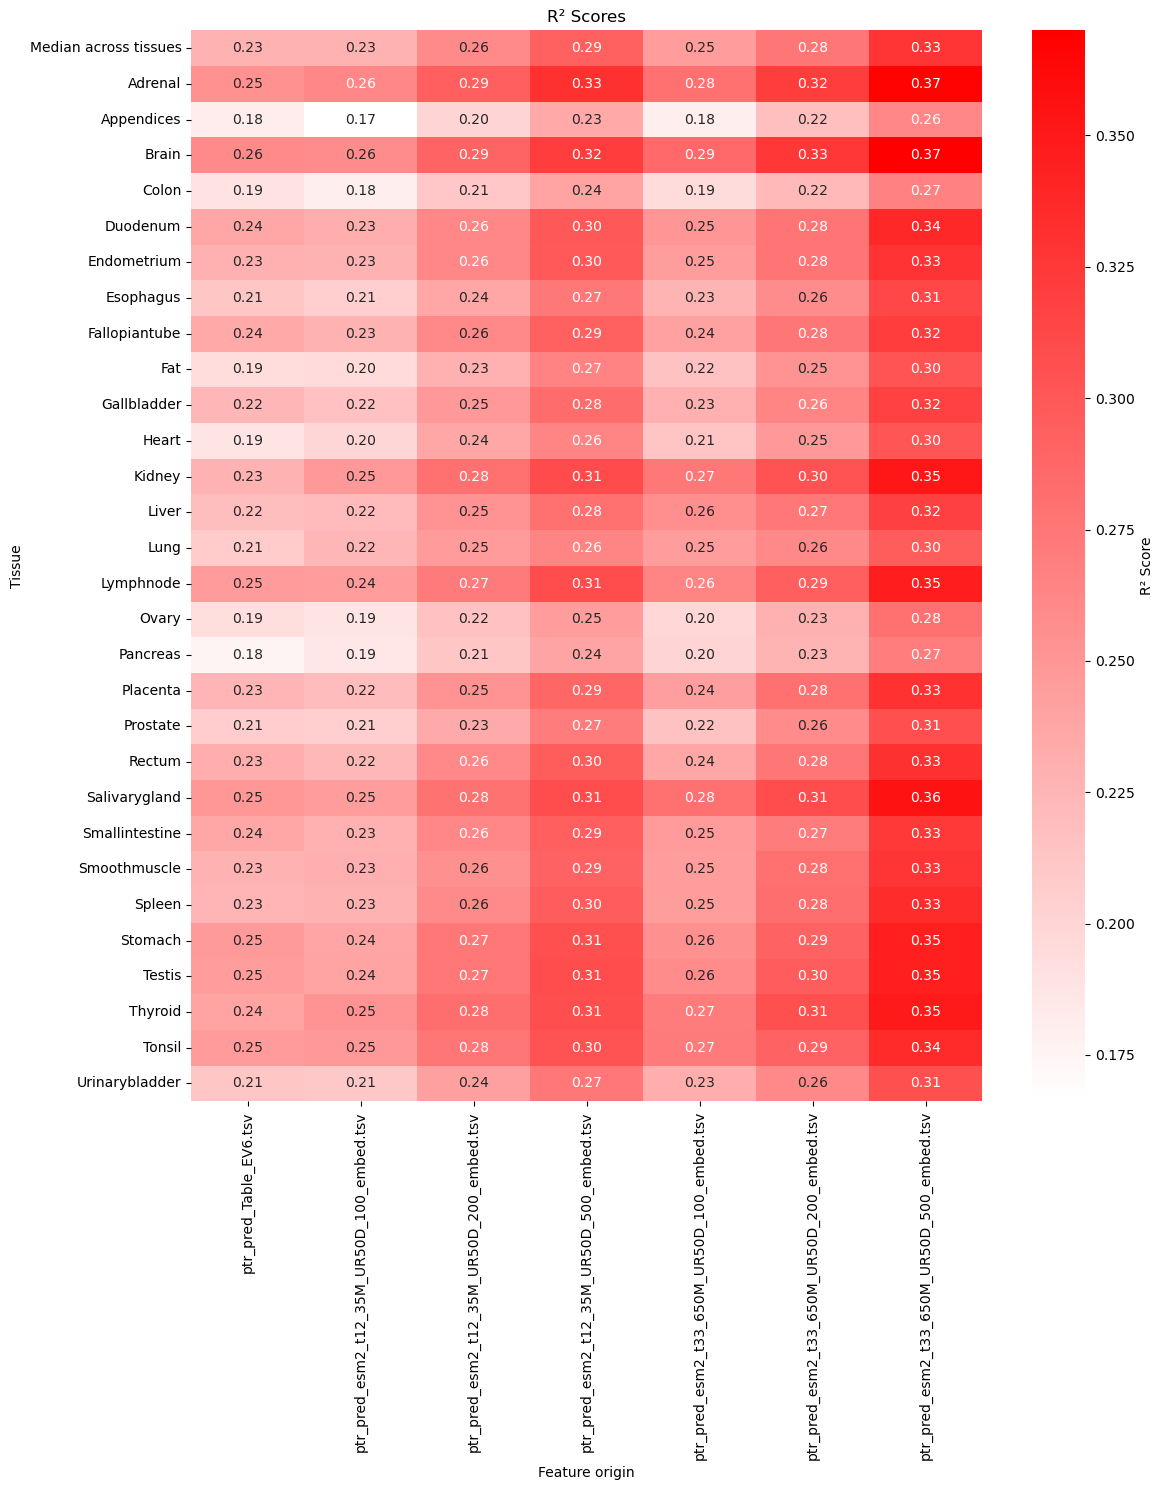

In [7]:
def generate_r2_heatmap(data_dir, file_pattern, sep='\t'):
    
    def r2_per_file(pred_file_path):
        pred_ptr_df = pd.read_csv(pred_file_path, sep=sep)
        r2_scores = []
        tissues = []

        for tissue in pred_ptr_df["tissue"].unique():
            observed = pred_ptr_df[pred_ptr_df['tissue'] == tissue]['PTR']
            predicted = pred_ptr_df[pred_ptr_df['tissue'] == tissue]['predicted_PTR']
            score = r2_score(observed, predicted)
            r2_scores.append(score)
            tissues.append(tissue)

        median_r2 = np.median(r2_scores)
        result_df = pd.DataFrame({
            'Tissue': tissues,
            'R²': r2_scores
        })
        median_row = pd.DataFrame({'Tissue': ['Median across tissues'], 'R²': [median_r2]})
        result_df = pd.concat([median_row, result_df], ignore_index=True)
        return result_df.set_index('Tissue')

    matched_files = sorted(
        [f for f in os.listdir(data_dir) if file_pattern in f and f.endswith('.tsv')]
    )

    all_results = pd.DataFrame()
    for filename in matched_files:
        file_path = os.path.join(data_dir, filename)
        r2_df = r2_per_file(file_path)
        all_results[filename] = r2_df['R²']

    all_results = all_results.reindex(
        ['Median across tissues'] + sorted([t for t in all_results.index if t != 'Median across tissues'])
    )

    cmap = LinearSegmentedColormap.from_list('white_red', ['white', 'red'])
    plt.figure(figsize=(12, max(6, len(all_results) * 0.5)))
    sns.heatmap(all_results, annot=True, fmt=".2f", cmap=cmap, cbar_kws={'label': 'R² Score'})
    plt.title('R² Scores')
    plt.ylabel('Tissue')
    plt.xlabel('Feature origin')
    plt.tight_layout()
    plt.show()

generate_r2_heatmap(data_dir='data', file_pattern='ptr_pred')